In [160]:
import requests
from io import BytesIO
import warnings
warnings.filterwarnings("ignore")
import os
import numpy as np
import random
import matplotlib.pyplot as plt
import pandas as pd
import pickle as pkl
import networkx as nx
import seaborn as sns
import scipy.stats as stats
np.random.seed(8888)
from scipy.spatial.distance import cdist
import lap
from numpy import linalg as LA
from multiprocessing import cpu_count

from sklearn.metrics.pairwise import pairwise_kernels

import graspologic
from graspologic.inference import latent_distribution_test
from graspologic.embed import AdjacencySpectralEmbed, OmnibusEmbed
from graspologic.simulations import sbm, rdpg
from graspologic.utils import symmetrize
from graspologic.plot import heatmap, pairplot

import igraph as ig
from igraph import *
from scipy.stats import norm
from scipy.sparse import csr_array
from sklearn.metrics import adjusted_rand_score
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import squareform


%matplotlib inline

In [322]:
def make_mat(filename):
    folderpath = "~/Desktop/papersandbooks/codes/shuffle/brain_data/"
    ext = ".ssv"
    
    filepath = os.path.join(folderpath, f"{filename}{ext}")
    
    obsdata = pd.read_csv(filepath, delimiter=" ", header=None, quotechar='"')

    edgelist = list(zip(obsdata[0], obsdata[1]))
    G = nx.Graph()
    G.add_edges_from(edgelist)
    
    if len(G.nodes) < 70:
        raise ValueError("Graph has fewer than 70 nodes.")
    adj_matrix = nx.to_numpy_array(G, nodelist=range(1,71))
    adj_matrix = pd.DataFrame(adj_matrix, index=range(1, 71), columns=range(1, 71))
    return adj_matrix

def full_list():
    patientID = [f"00{n}" for n in range(25427, 25457)]
    filenamelist = []
    for i in range(300):
        PatID = patientID[(i // 10)]
        scanID = (i % 10) if (i % 10) != 0 else 10
        name = f"sub-{PatID}_ses-{scanID}_dwi_desikan"
        filenamelist.append(name)
    adj_mats = [make_mat(filename) for filename in filenamelist]
    return adj_mats

def get_adjs_shuffle_unshuff(adj_mat_list_full, k_shuff):
    shuffled_adjs = []
    shuf_part_adjs = []
    unshuf_part_adjs = []
    order_original = list(range(1, 71)) #list(adj1.index)
    vertex_shuffled = np.random.choice(order_original, k_shuff, replace=False)
    unshuf = [item for item in order_original if item not in vertex_shuffled]
    # reorder_vertex = np.concatenate((unshuf, vertex_shuffled))
    for index, adj in enumerate(adj_mat_list_full):
        np.random.shuffle(vertex_shuffled)
        reorder_vertex = np.concatenate((unshuf, vertex_shuffled))
        unshuf_adj = adj.loc[unshuf][unshuf] # only the unshuf parts of the adj
        shuf_part_adj = adj.loc[vertex_shuffled][vertex_shuffled]# only the shuffled parts of the adj
        shuf_adj = adj.loc[reorder_vertex][reorder_vertex] # adj with shuffled points
        shuffled_adjs.append(shuf_adj)
        shuf_part_adjs.append(shuf_part_adj)
        unshuf_part_adjs.append(unshuf_adj)

    return shuffled_adjs, shuf_part_adjs, unshuf_part_adjs

def get_adjs_unshuffle(adj1, k_shuff):
    order_original = list(adj1.index)
    vertex_shuffled = np.random.choice(order_original, k_shuff, replace=False)
    unshuf = [item for item in order_original if item not in vertex_shuffled]
    reorder_vertex = np.concatenate((unshuf, vertex_shuffled))
    unshuf_adj = adj1.loc[unshuf][unshuf].to_numpy() # only the unshuf parts of the adj
    shuf_adj = adj1.loc[reorder_vertex][reorder_vertex].to_numpy() # adj with shuffled points
    shuf_part_adj = adj1.loc[vertex_shuffled][vertex_shuffled].to_numpy()# only the shuffled parts of the adj

    return shuf_part_adj, unshuf_adj

def aseoos(Xhat, avec):
    n = Xhat.shape[0]
    
    if len(avec) != n:
        raise ValueError("Length of edge vector avec does not match size of latent position matrix Xhat.")
    ooshat = np.linalg.lstsq(Xhat.T @ Xhat, Xhat.T @ avec, rcond=None)[0]
    
    return ooshat

def pairwise_distances(embeddings):
    n = len(embeddings)
    distances = np.zeros((n, n))
    for i in range(n):
        for j in range(i, n):
            norm = LA.norm(embeddings[i] - embeddings[j], ord='fro') ** 2
            distances[i, j] = norm
            distances[j, i] = norm 
    return distances

def plot_distance_matrix(distance_matrix):
    #plt.figure(figsize=(10, 10))
    unique_vals = np.unique(distance_matrix)
    second_min = unique_vals[1]
    sns.heatmap(distance_matrix,  cmap='plasma_r',  cbar=True,vmin=second_min, vmax=np.max(distance_matrix)) #fmt=".1f", annot=True, ,vmin=30, vmax=50
    plt.title("Pairwise Distances Among Brain Scans")
    plt.xlabel("Brains")
    plt.ylabel("Brains")
    plt.show()

def get_clusters_avg(dist_matrix,method='complete',t=10):
    condensed = squareform(dist_matrix)
    Z = linkage(condensed, method=method)
    labels = fcluster(Z, t=t, criterion='maxclust')
    # plt.figure(figsize=(10, 5))
    # dendrogram(Z,labels=labels)
    # plt.title("Hierarchical Clustering Dendrogram")
    # plt.xlabel("Sample index")
    # plt.ylabel("Distance")
    # plt.xticks(rotation=90)
    # plt.tight_layout()
    # plt.show()
    return labels


In [283]:
adj_mat_list_full = full_list()

In [11]:
k = 20
dim = 7
shuffled_adjs, shuf_part_adjs, unshuf_part_adjs = get_adjs_shuffle_unshuff(adj_mat_list_full,k)


(100, 100)


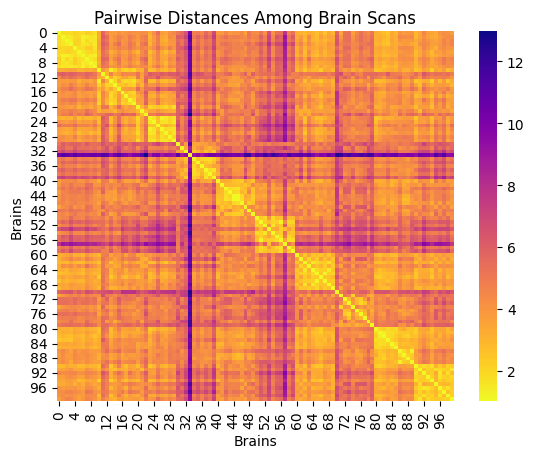

In [284]:
# select number of subjects
num_graphs = 100 
group_keys_20 = range(num_graphs)
group_20 = adj_mat_list_full[0:num_graphs]
group_adj_20 = shuffled_adjs[0:num_graphs]
group_unshuf_20 = unshuf_part_adjs[0:num_graphs]
group_shuf_20 = shuf_part_adjs[0:num_graphs]
# get all the graphs together with partial shuffled points
omni_embedder = OmnibusEmbed(n_components = dim)
Zhatsall = omni_embedder.fit_transform([df.to_numpy() for df in group_adj_20])
distance_matrix = pairwise_distances(Zhatsall)
print(distance_matrix.shape)
plot_distance_matrix(distance_matrix)

(100, 50, 7)
(100, 100)


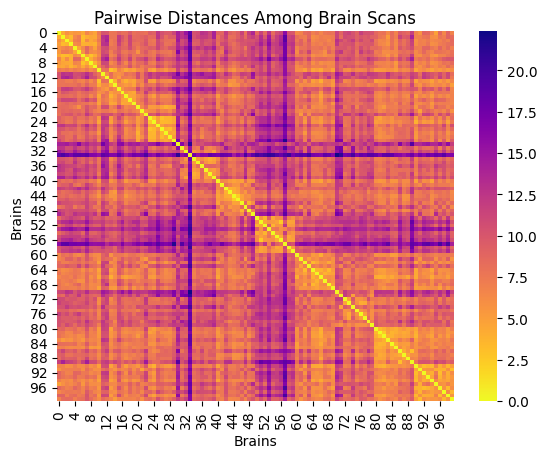

In [17]:
Zhatsall_unshuf = omni_embedder.fit_transform([df.to_numpy() for df in group_unshuf_20])  #[df.to_numpy() for df in group_unshuf_20]
print(Zhatsall_unshuf.shape)
embeddings=[]
#for p in range(n_graphs):
for key, adj in enumerate(group_20):
    #graph_adj = m_graph_adjs_shuffled[p]
    oosB = np.zeros((k, dim))
    for i in range(k):
        shuffle_vector = adj.iloc[70-k+i, :(70-k)].to_numpy()
        #key_index = keys.index(key)
        point_est = aseoos(Zhatsall_unshuf[key], shuffle_vector)
        oosB[i, :] = point_est
    # calculate distance and match order
    #dists = cdist(oosA, oosB, 'euclidean')
    #cost, x1, y1 = lap.lapjv(dists)
    #oosB_2 = oosB[x1]
    #newB_xs = np.vstack((Zhats_m[p], oosB_2))
    newB_xs = np.vstack((Zhatsall_unshuf[key], oosB))
    embeddings.append(newB_xs)
distance_matrix2 = pairwise_distances(embeddings)
print(distance_matrix2.shape)
plot_distance_matrix(distance_matrix2)

(100, 100)


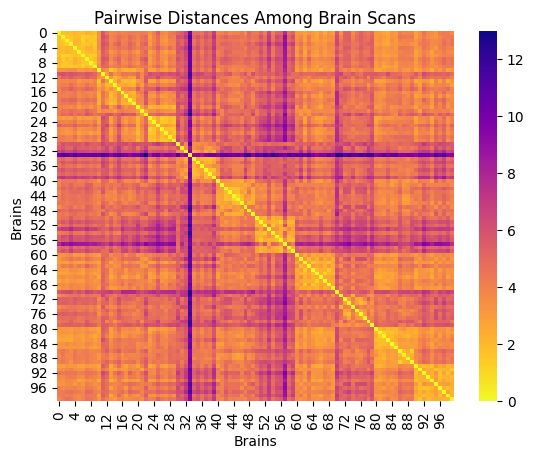

In [18]:
k = 20
dim = 7
shuffled_adjs, shuf_part_adjs, unshuf_part_adjs = get_adjs_shuffle_unshuff(adj_mat_list_full,k)
random.seed(42)
# select number of subjects
num_graphs = 100 
group_keys_20 = range(num_graphs)
group_20 = adj_mat_list_full[0:num_graphs]
group_adj_20 = shuffled_adjs[0:num_graphs]
group_unshuf_20 = unshuf_part_adjs[0:num_graphs]
group_shuf_20 = shuf_part_adjs[0:num_graphs]
# get all the graphs together with partial shuffled points
omni_embedder = OmnibusEmbed(n_components = dim)
Zhatsall = omni_embedder.fit_transform([df.to_numpy() for df in group_adj_20])
distance_matrix = pairwise_distances(Zhatsall)
print(distance_matrix.shape)
plot_distance_matrix(distance_matrix)

(100, 50, 7)
(100, 100)


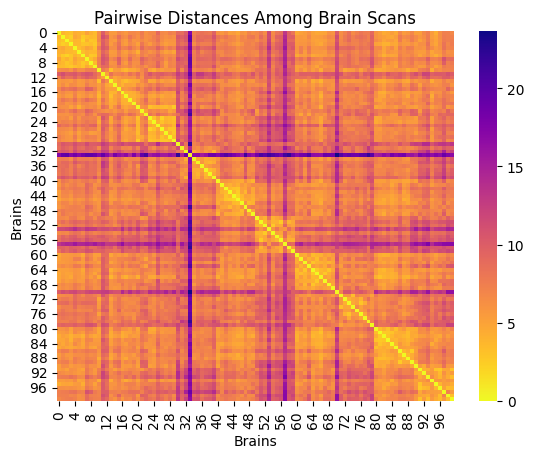

In [19]:
Zhatsall_unshuf = omni_embedder.fit_transform([df.to_numpy() for df in group_unshuf_20])  #[df.to_numpy() for df in group_unshuf_20]
print(Zhatsall_unshuf.shape)
embeddings=[]
#for p in range(n_graphs):
for key, adj in enumerate(group_20):
    #graph_adj = m_graph_adjs_shuffled[p]
    oosB = np.zeros((k, dim))
    for i in range(k):
        shuffle_vector = adj.iloc[70-k+i, :(70-k)].to_numpy()
        #key_index = keys.index(key)
        point_est = aseoos(Zhatsall_unshuf[key], shuffle_vector)
        oosB[i, :] = point_est
    # calculate distance and match order
    #dists = cdist(oosA, oosB, 'euclidean')
    #cost, x1, y1 = lap.lapjv(dists)
    #oosB_2 = oosB[x1]
    #newB_xs = np.vstack((Zhats_m[p], oosB_2))
    newB_xs = np.vstack((Zhatsall_unshuf[key], oosB))
    embeddings.append(newB_xs)
distance_matrix2 = pairwise_distances(embeddings)
print(distance_matrix2.shape)
plot_distance_matrix(distance_matrix2)

In [334]:
true_labels = np.repeat(np.arange(1, 11), 10)

dist_omni = []
dist_omnimatch = []
dist_pairwise = []
ari_omni = []
ari_anchor = []
ari_pairwise = []
aris_tt_omni= []
aris_tt_anchor = []
aris_tt_pair = []

nMC = 200

for i in range(nMC):
    k = 20
    dim = 7
    shuffled_adjs, shuf_part_adjs, unshuf_part_adjs = get_adjs_shuffle_unshuff(adj_mat_list_full,k)
    group_keys_20 = range(num_graphs)
    group_20 = adj_mat_list_full[0:num_graphs] # original adjs
    group_adj_20 = shuffled_adjs[0:num_graphs] # all
    group_unshuf_20 = unshuf_part_adjs[0:num_graphs] # only unshuf parts
    group_shuf_20 = shuf_part_adjs[0:num_graphs] # only shuf parts

    # Omni only
    # get all the graphs together including partial shuffled points
    omni_embedder = OmnibusEmbed(n_components = dim)
    Zhatsall = omni_embedder.fit_transform([df.to_numpy() for df in group_adj_20])
    distance_matrix = pairwise_distances(Zhatsall)
    dist_omni.append(distance_matrix)

    labels = get_clusters_avg(distance_matrix)
    ari1 = adjusted_rand_score(true_labels, labels)
    aris_tt_omni.append(ari1)

    # Omnimatch using last graph as anchor to match
    Zhatsall_unshuf = omni_embedder.fit_transform([df.to_numpy() for df in group_unshuf_20])  #[df.to_numpy() for df in group_unshuf_20]
    embeddings=[]
    anchor_graph = group_adj_20[num_graphs-1]
    oosA = np.zeros((k, dim))
    for i in range(k):
        shuffle_vector = anchor_graph.iloc[70-k+i, :(70-k)].to_numpy()
        point_est = aseoos(Zhatsall_unshuf[num_graphs-1], shuffle_vector)
        oosA[i, :] = point_est
    newA_xs = np.vstack((Zhatsall_unshuf[num_graphs-1], oosA))

    for key, adj in enumerate(group_adj_20): ### group_20
        oosB = np.zeros((k, dim))
        for i in range(k):
            shuffle_vector = adj.iloc[70-k+i, :(70-k)].to_numpy()
            point_est = aseoos(Zhatsall_unshuf[key], shuffle_vector)
            oosB[i, :] = point_est
        # calculate distance and match order
        dists = cdist(oosA, oosB, 'euclidean')
        cost, x1, y1 = lap.lapjv(dists)
        oosB_2 = oosB[x1]
        newB_xs = np.vstack((Zhatsall_unshuf[key], oosB_2))
        embeddings.append(newB_xs)
    embeddings[num_graphs-1] = newA_xs
    distance_matrix2 = pairwise_distances(embeddings)
    dist_omnimatch.append(distance_matrix2)

    labels = get_clusters_avg(distance_matrix2)
    ari1 = adjusted_rand_score(true_labels, labels)
    aris_tt_anchor.append(ari1)

    # Omnimatch pairwise match
    embeddings2 = []
    for p in range(100):
        graph_adj = group_adj_20[p]
        oosB = np.zeros((k, dim))
        for i in range(k):
            shuffle_vector = graph_adj.iloc[70-k+i, :(70-k)].to_numpy()
            point_est = aseoos(Zhatsall_unshuf[p], shuffle_vector)
            oosB[i, :] = point_est
        newB_xs = np.vstack((Zhatsall_unshuf[p], oosB))
        embeddings2.append(newB_xs)

    cost_matrix = np.zeros((len(embeddings2), len(embeddings2)))
    for i in range(len(embeddings2)):
        for k in range(len(embeddings2)):
            if i == k:
                cost_matrix[i, k] = 0
            else:
                A_emb = embeddings2[i]
                B_emb = embeddings2[k]
                dists = cdist(A_emb, B_emb, 'euclidean')
                cost, x1, y1 = lap.lapjv(dists)
                cost_matrix[i, k] = cost
    dist_pairwise.append(cost_matrix)

    test = (cost_matrix + cost_matrix.T) / 2
    labels = get_clusters_avg(test)
    ari1 = adjusted_rand_score(true_labels, labels)
    aris_tt_pair.append(ari1)

labels_omni = get_clusters_avg(mean(dist_omni))
labels_anchor = get_clusters_avg(mean(dist_omnimatch))
test = (np.mean(dist_pairwise, axis=0) + np.mean(dist_pairwise, axis=0).T) / 2
np.fill_diagonal(test, 0)
labels_pariwise = get_clusters_avg(test) 

ari1 = adjusted_rand_score(true_labels, labels_omni)
ari_omni.append(ari1)
ari2 = adjusted_rand_score(true_labels, labels_anchor)
ari_anchor.append(ari2)
ari3 = adjusted_rand_score(true_labels, labels_pariwise)
ari_pairwise.append(ari3)


In [335]:
print(ari_omni,ari_anchor,ari_pairwise)
print(mean(aris_tt_omni))
print(mean(aris_tt_anchor))
print(mean(aris_tt_pair))

[0.5619143239625167] [0.5973645680819912] [0.5563282336578581]
0.2897269391113926
0.4373826376375439
0.5131674682695585


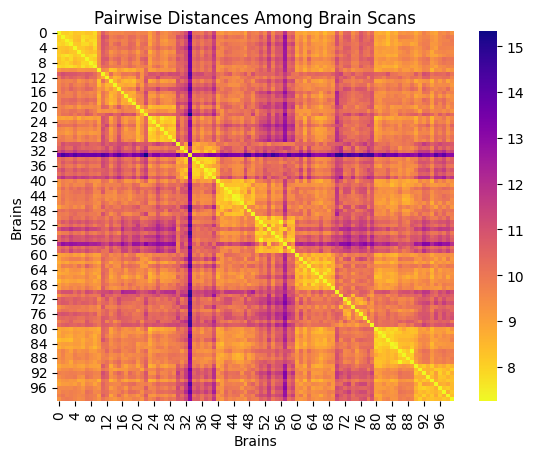

In [336]:
plot_distance_matrix(mean(dist_omni))

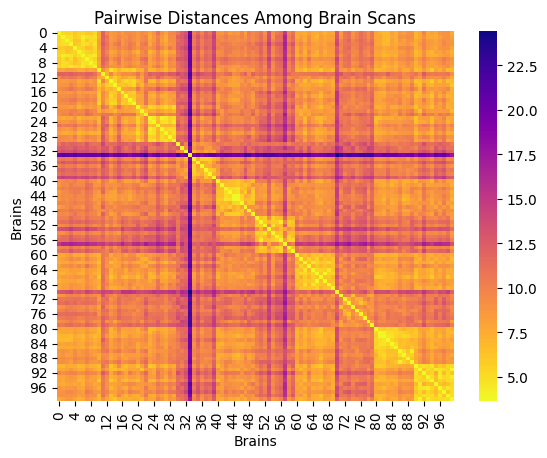

In [337]:
plot_distance_matrix(mean(dist_omnimatch))

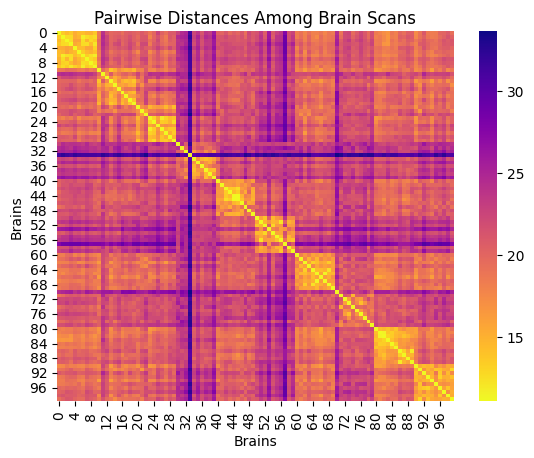

In [338]:
plot_distance_matrix(mean(dist_pairwise))

In [333]:
print(mean(ari_omni))
print(mean(ari_anchor))
print(mean(ari_pairwise))

0.3943191311612364
0.35725098395398125
0.4438964241676942


In [298]:
dist_omni = []
tt = []
for test in range(3):
    k = 20
    shuffled_adjs, shuf_part_adjs, unshuf_part_adjs = get_adjs_shuffle_unshuff(adj_mat_list_full,k)
    print(shuf_part_adjs[0].shape)
    group_keys_20 = range(num_graphs)
    group_20 = adj_mat_list_full[0:num_graphs] # original adjs
    group_adj_20 = shuffled_adjs[0:num_graphs] # all
    group_unshuf_20 = unshuf_part_adjs[0:num_graphs] # only unshuf parts
    group_shuf_20 = shuf_part_adjs[0:num_graphs] # only shuf parts

    # Omni only
    # get all the graphs together including partial shuffled points
    omni_embedder = OmnibusEmbed(n_components = dim)
    Zhatsall = omni_embedder.fit_transform([df.to_numpy() for df in group_adj_20])
    distance_matrix = pairwise_distances(Zhatsall)
    dist_omni.append(distance_matrix)

    condensed = squareform(distance_matrix)
    Z = linkage(condensed, method='complete')
    labels = fcluster(Z, t=10, criterion='maxclust')
    print(labels)

    #labels_omni = get_clusters_avg(distance_matrix)
    ari1 = adjusted_rand_score(true_labels, labels)
    tt.append(ari1)
    print(ari1)

    k = 50
    shuffled_adjs, shuf_part_adjs, unshuf_part_adjs = get_adjs_shuffle_unshuff(adj_mat_list_full,k)
    print(shuf_part_adjs[0].shape)
    group_keys_20 = range(num_graphs)
    group_20 = adj_mat_list_full[0:num_graphs] # original adjs
    group_adj_202 = shuffled_adjs[0:num_graphs] # all
    group_unshuf_20 = unshuf_part_adjs[0:num_graphs] # only unshuf parts
    group_shuf_20 = shuf_part_adjs[0:num_graphs] # only shuf parts

    # Omni only
    # get all the graphs together including partial shuffled points
    omni_embedder = OmnibusEmbed(n_components = dim)
    Zhatsall = omni_embedder.fit_transform([df.to_numpy() for df in group_adj_202])
    distance_matrix = pairwise_distances(Zhatsall)
    dist_omni.append(distance_matrix)

    condensed = squareform(distance_matrix)
    Z = linkage(condensed, method='complete')
    labels = fcluster(Z, t=10, criterion='maxclust') # distance
    print(labels)

    #labels_omni = get_clusters_avg(distance_matrix)
    ari1 = adjusted_rand_score(true_labels, labels)
    tt.append(ari1)
    print(ari1)


(20, 20)
[ 4  4  4  4  4  4  4  4  4  4  2  2  2  2  2  2  2  2  2  2  4  3  3  4
  4  4  4  4  4  4  9  8  8 10  9  9  9  8  9  8  6  6  6  6  6  6  6  6
  6  6  6  6  6  7  6  6  6  7  6  6  3  3  3  3  3  3  3  3  3  3  5  3
  1  1  3  1  1  1  3  1  4  4  4  4  4  4  4  4  4  4  4  4  4  4  4  4
  4  4  4  4]
0.41197872935908203
(50, 50)
[ 4  4  4  4  4  4  4  4  4  4  2  2  2  2  2  2  2  2  2  2  4  3  3  4
  4  4  4  4  4  4  9  8  8 10  9  9  9  8  9  8  6  6  6  6  6  6  6  6
  6  6  6  6  6  7  6  6  6  7  6  6  3  3  3  3  3  3  3  3  3  3  5  3
  1  1  3  1  1  1  3  1  4  4  4  4  4  4  4  4  4  4  4  4  4  4  4  4
  4  4  4  4]
0.41197872935908203
(20, 20)
[ 4  4  4  4  4  4  4  4  4  4  2  2  2  2  2  2  2  2  2  2  4  3  3  4
  4  4  4  4  4  4  9  8  8 10  9  9  9  8  9  8  6  6  6  6  6  6  6  6
  6  6  6  6  6  7  6  6  6  7  6  6  3  3  3  3  3  3  3  3  3  3  5  3
  1  1  3  1  1  1  3  1  4  4  4  4  4  4  4  4  4  4  4  4  4  4  4  4
  4  4  4  4]
0.4119787293590

In [315]:
are_equal = group_adj_20[1].equals(group_adj_202[1])
print("DataFrames are equal:", are_equal)

DataFrames are equal: False


In [317]:
len(adj_mat_list_full)

300

In [318]:
order_original = list(range(1, 71)) #list(adj1.index)
vertex_shuffled = np.random.choice(order_original, 70, replace=False)
unshuf = [item for item in order_original if item not in vertex_shuffled]
reorder_vertex = np.concatenate((unshuf, vertex_shuffled))
for index, adj in enumerate(adj_mat_list_full[0:100]):
    np.random.shuffle(vertex_shuffled)
    unshuf_adj = adj.loc[unshuf][unshuf] # only the unshuf parts of the adj
    shuf_part_adj = adj.loc[vertex_shuffled][vertex_shuffled]# only the shuffled parts of the adj
    shuf_adj = adj.loc[reorder_vertex][reorder_vertex] # adj with shuffled po

100

In [255]:
shuffled_adjs, shuf_part_adjs, unshuf_part_adjs = get_adjs_shuffle_unshuff(adj_mat_list_full,k)

,2,3,4,5,6,7,9,10,12,13,...,33,23,48,62,50,28,8,42,57,1
2,0.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
3,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,...,1.0,0.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0
4,1.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,...,0.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0
5,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,...,0.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0
6,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28,0.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
8,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,...,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
42,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
57,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [306]:
def is_symmetric(matrix, tol=1e-8):
    return print(np.allclose(matrix, matrix.T, atol=tol))
is_symmetric(cost_matrix)
is_symmetric(mean(dist_omni))
is_symmetric(mean(dist_omnimatch))

True
True
True


In [140]:
true_labels = np.repeat(np.arange(1, 11), 10)  # labels 1 to 10, each repeated 10 times
print(true_labels)

[ 1  1  1  1  1  1  1  1  1  1  2  2  2  2  2  2  2  2  2  2  3  3  3  3
  3  3  3  3  3  3  4  4  4  4  4  4  4  4  4  4  5  5  5  5  5  5  5  5
  5  5  6  6  6  6  6  6  6  6  6  6  7  7  7  7  7  7  7  7  7  7  8  8
  8  8  8  8  8  8  8  8  9  9  9  9  9  9  9  9  9  9 10 10 10 10 10 10
 10 10 10 10]


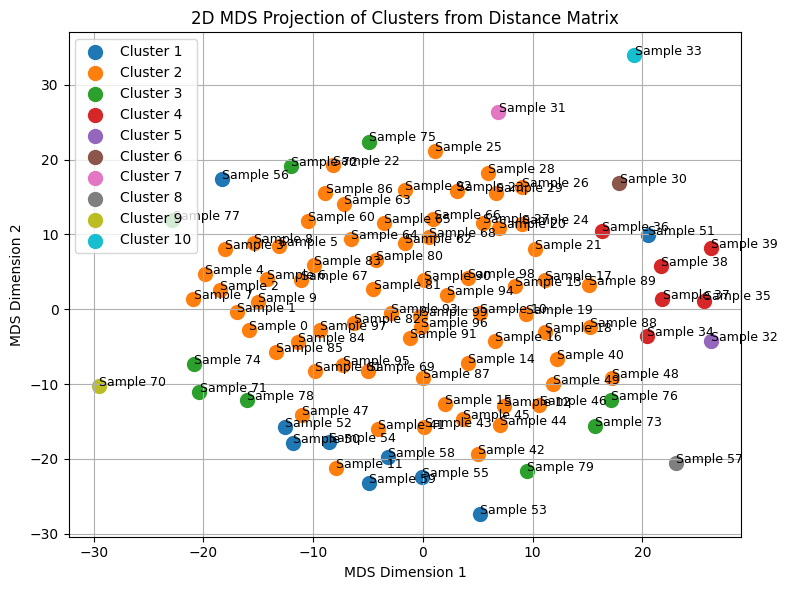

In [171]:
from sklearn.manifold import MDS

mds = MDS(n_components=2, dissimilarity='precomputed', random_state=42)
projected = mds.fit_transform(mean(dist_omnimatch))
plt.figure(figsize=(8, 6))

# Plot each cluster in a different color
for cluster_id in np.unique(labels_anchor):
    idx = labels_anchor == cluster_id
    plt.scatter(projected[idx, 0], projected[idx, 1],
                label=f'Cluster {cluster_id}', s=100)

# Annotate each point
for i, (x, y) in enumerate(projected):
    plt.text(x + 0.01, y + 0.01, f'Sample {i}', fontsize=9)

# Final touches
plt.title("2D MDS Projection of Clusters from Distance Matrix")
plt.xlabel("MDS Dimension 1")
plt.ylabel("MDS Dimension 2")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


array([[0.        , 1.79472131, 1.84537097, ..., 4.19770136, 4.10763561,
        3.71446956],
       [1.79472131, 0.        , 1.47073158, ..., 4.21967204, 4.29069982,
        4.19545026],
       [1.84537097, 1.47073158, 0.        , ..., 4.5722408 , 4.02054666,
        4.62940871],
       ...,
       [4.19770136, 4.21967204, 4.5722408 , ..., 0.        , 2.69796243,
        2.16154879],
       [4.10763561, 4.29069982, 4.02054666, ..., 2.69796243, 0.        ,
        2.16090712],
       [3.71446956, 4.19545026, 4.62940871, ..., 2.16154879, 2.16090712,
        0.        ]])

In [121]:
#test =np.asarray(np.mean(dist_pairwise, axis=0), dtype=float) 
dist_matrix = (np.mean(dist_pairwise, axis=0) + np.mean(dist_pairwise, axis=0).T) / 2
np.fill_diagonal(dist_matrix, 0)
condensed = squareform(dist_matrix)


In [133]:
distance_matrix2.shape

(101, 101)

In [143]:
ari = adjusted_rand_score(true_labels, labels_pariwise)
print(ari)

0.22757151276123125


In [116]:
def is_valid_for_squareform(D, tol=1e-8):
    return (
        D.shape[0] == D.shape[1]
        and np.allclose(D, D.T, atol=tol)
        and np.allclose(np.diag(D), 0, atol=tol)
    )

print("Matrix is valid for squareform:", is_valid_for_squareform(mean(dist_pairwise)))


Matrix is valid for squareform: True


(100, 100)


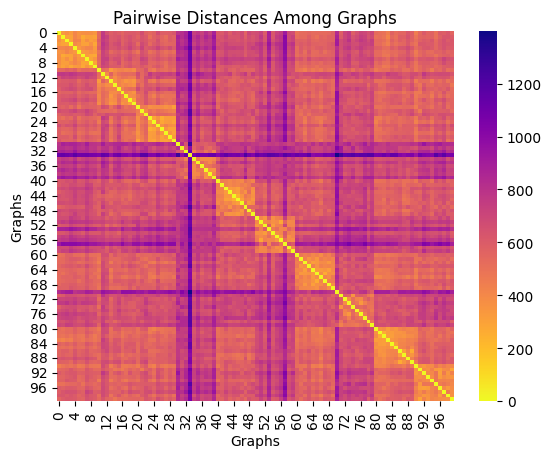

In [217]:
distance_matrix = pairwise_distances(adj_mat_list_full[0:num_graphs])
print(distance_matrix.shape)
plot_distance_matrix(distance_matrix)

In [201]:
# shuffled_parts = {}
# unshuffled_parts = {}
# for key, adj in adjacency_matrices.items():
#     shuff_part, unshuff_part = get_adjs_unshuffle(adj,k_shuff = k)
#     shuffled_adjs[key]=shuff_part
#     unshuffled_parts[key] = unshuff_part

In [36]:
Zhatsall_unshuf.shape

(300, 60, 5)

In [61]:
embeddings=[]
#for p in range(n_graphs):
for key, adj in adjacency_matrices.items():
    #graph_adj = m_graph_adjs_shuffled[p]
    oosB = np.zeros((k, dim))
    for i in range(k):
        shuffle_vector = adj.iloc[70-k+i, :(70-k)].to_numpy()
        key_index = keys.index(key)
        point_est = aseoos(Zhatsall_unshuf[key_index], shuffle_vector)
        oosB[i, :] = point_est
    # calculate distance and match order
    #dists = cdist(oosA, oosB, 'euclidean')
    #cost, x1, y1 = lap.lapjv(dists)
    #oosB_2 = oosB[x1]
    #newB_xs = np.vstack((Zhats_m[p], oosB_2))
    newB_xs = np.vstack((Zhatsall_unshuf[key_index], oosB))
    embeddings.append(newB_xs)

In [62]:
distance_matrix2 = pairwise_distances(embeddings)

In [63]:
distance_matrix2.shape

(300, 300)

In [82]:
from sklearn.decomposition import TruncatedSVD
def find_elbow(matrix):
    # Perform SVD on the adjacency matrix
    svd = TruncatedSVD(n_components=min(matrix.shape)-1)  # Set the max components to min(matrix)
    svd.fit(matrix)
    
    # Extract singular values
    singular_values = svd.singular_values_
    
    # Compute the first derivative to find the elbow
    diffs = np.diff(singular_values)
    
    # Plot the singular values to visualize the elbow
    plt.plot(singular_values, marker='o')
    plt.title('Singular Values of the Adjacency Matrix')
    plt.xlabel('Component index')
    plt.ylabel('Singular Value')
    plt.show()
    
    # Plot the differences (first derivative) to find the elbow
    plt.plot(diffs, marker='o')
    plt.title('First Derivative of Singular Values')
    plt.xlabel('Component index')
    plt.ylabel('Difference in Singular Values')
    plt.show()
    
    # Identify the elbow as the point of largest change in derivative
    elbow_index = np.argmax(diffs)
    print(f"Elbow index: {elbow_index}")
    return elbow_index


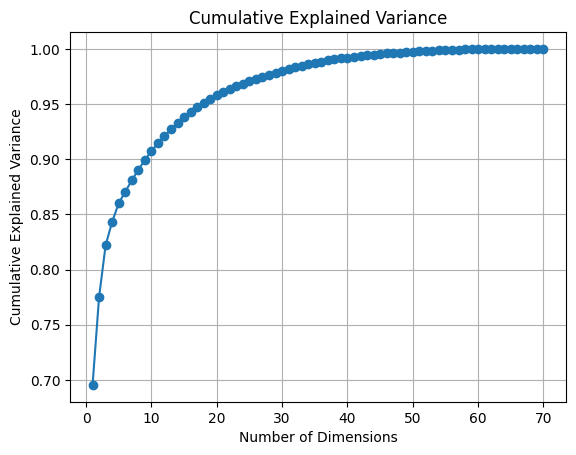

The elbow is at dimension: 7


In [84]:
U, S, Vt = np.linalg.svd(adjacency_matrices[key], full_matrices=False)

# Compute the explained variance (squared singular values)
explained_variance = (S ** 2) / np.sum(S ** 2)

# Cumulative explained variance
cumulative_variance = np.cumsum(explained_variance)

# Plot cumulative variance
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o')
plt.title('Cumulative Explained Variance')
plt.xlabel('Number of Dimensions')
plt.ylabel('Cumulative Explained Variance')
plt.grid(True)
plt.show()

# Find the elbow point (a common heuristic)
elbow_index = np.argmax(np.diff(cumulative_variance) < 0.01)  # or some threshold
print(f"The elbow is at dimension: {elbow_index + 1}")

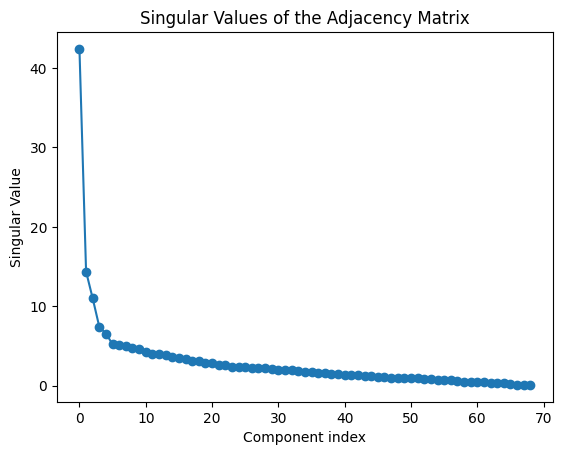

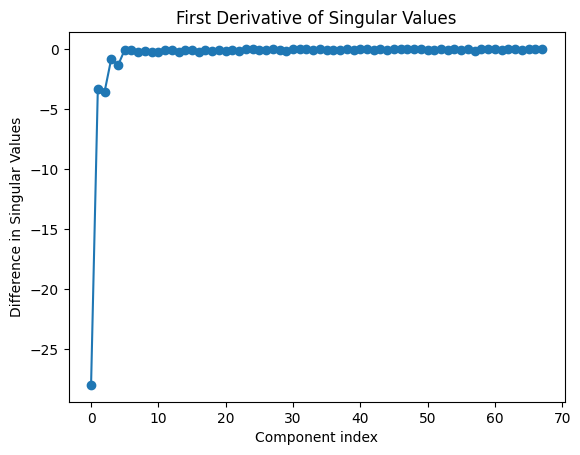

Elbow index: 46


46

In [83]:
find_elbow(adjacency_matrices[key])

In [203]:
oosA = np.zeros((k, dim))
shuffle_vector = anchor_graph[500-kshuff[j]+i, :(500-kshuff[j])]
point_est = aseoos(Zhats_m[m-1], shuffle_vector)
oosA[i, :] = point_est
newA_xs = np.vstack((Zhats_m[m-1], oosA))
embeddings=[]
for p in range(n_graphs-1):
    graph_adj = all_shuffled_parts[p]
    oosB = np.zeros((k, dim))
    for i in range(k):
        shuffle_vector = graph_adj[500-k+i, :(500-k)]
        point_est = aseoos(Zhatsall_unshuf[p], shuffle_vector)
        oosB[i, :] = point_est
    # calculate distance and match order
    dists = cdist(oosA, oosB, 'euclidean')
    cost, x1, y1 = lap.lapjv(dists)
    oosB_2 = oosB[x1]
    newB_xs = np.vstack((Zhats_m[p], oosB_2))
    oosB_avg = soft_matching_estimate(dists,oosB,vertex_shuffled)
    newB_xs_avg = np.vstack((MB_xhat, oosB_avg))
    embeddings.append(newB_xs)
embeddings.append(newA_xs)

(10, 10)

In [117]:
def load_graphml_from_links(base_url, num_subjects=57, num_scans=2):
    adjacency_matrices = {}  
    graphs = {}  

    for subject in range(1, num_subjects + 1):
        subject_graphs = {}  

        for scan in range(1, 3):  
            url = base_url.format(subject=subject, scan=scan)

            try:
                response = requests.get(url)
                response.raise_for_status()  

                graph_data = BytesIO(response.content)
                G = nx.read_graphml(graph_data)

                nodes_to_remove = [n for n, attr in G.nodes(data=True)
                                   if attr.get("hemisphere") == "none" or attr.get("tissue") == "none"]
                G.remove_nodes_from(nodes_to_remove)

                subject_graphs[scan] = G

            except requests.exceptions.RequestException as e:
                print(f"Failed to fetch subject {subject}, scan {scan}: {e}")

        if 1 in subject_graphs and 2 in subject_graphs:
            common_nodes = set(subject_graphs[1].nodes()) & set(subject_graphs[2].nodes())

            subject_graphs[1] = subject_graphs[1].subgraph(common_nodes).copy()
            subject_graphs[2] = subject_graphs[2].subgraph(common_nodes).copy()

            adjacency_matrices[(subject, 1)] = nx.to_pandas_adjacency(subject_graphs[1])
            adjacency_matrices[(subject, 2)] = nx.to_pandas_adjacency(subject_graphs[2])

    return adjacency_matrices


def aseoos(Xhat, avec):
    n = Xhat.shape[0]
    
    if len(avec) != n:
        raise ValueError("Length of edge vector avec does not match size of latent position matrix Xhat.")
    
    # solve Xhat @ ooshat = avec
    # (really we're solving the linear least squares)
    ooshat = np.linalg.lstsq(Xhat.T @ Xhat, Xhat.T @ avec, rcond=None)[0]
    
    return ooshat

def array_split(data, m):
    rowIdx = np.arange(data.shape[0])
    # Split row indices into m groups
    split_indices = np.array_split(rowIdx, m)
    
    # Use the split indices to split the data array
    split_data = [data[x, :] for x in split_indices]
    
    return split_data

def check_repeated_rows(df):
    # Use duplicated() method to check for repeated rows
    duplicated_rows = df[df.duplicated()]
    if not duplicated_rows.empty:
        print("There are repeated rows.")
        print(duplicated_rows)
        print('numer is',duplicated_rows.shape )
    else:
        print("No repeated rows.")

def find_smallest_columns(row, num=5):# edit the k for softmatching
    return np.array(row.nsmallest(num).index)

def soft_matching_estimate(dists, oosB,vertex_shuffled,dim=10):
    dists_df = pd.DataFrame(dists)
    #ranked_df = dists_df.rank(axis=1, method='min')  # Using 'min' method for ranking
    dists_df.columns = [vertex_shuffled] #vertex_shuffled2
    dists_df.index = [vertex_shuffled]  
    #sorted_df = pd.DataFrame(np.sort(dists, axis=1), index=dists_df.index, columns=dists_df.columns)
    #check_repeated_rows(dists_df)
    smallest_columns = dists_df.apply(find_smallest_columns, axis=1)
    flattened_5cols = []
    for row in smallest_columns:
        flattened_5cols.append([item[0] for item in row])
    oosB_df = pd.DataFrame(oosB)
    oosB_df.index = [vertex_shuffled] 
    oosB_avg = np.zeros((len(vertex_shuffled), dim))
    for i in range(len(vertex_shuffled)):
        avg = np.array(oosB_df.loc[flattened_5cols[i]].mean())
        oosB_avg[i,:] = avg

    return oosB_avg

In [15]:
# def load_graphml_as_matrix(url):
#     response = requests.get(url)
#     if response.status_code != 200:
#         raise ValueError(f"Failed to fetch data from {url}")

#     graph_data = BytesIO(response.content)
#     G = nx.read_graphml(graph_data)

#     adj_matrix = nx.to_pandas_adjacency(G)

#     return adj_matrix

# url = "https://www.cis.jhu.edu/~parky/Microsoft/JHU-MSR/ZMx2/BNU1/DS01216/subj16-scan1.graphml"


# adj_matrix = load_graphml_as_matrix(url)
# print(adj_matrix)

In [41]:
base_url = "https://www.cis.jhu.edu/~parky/Microsoft/JHU-MSR/ZMx2/BNU1/DS01216/subj{subject}-scan{scan}.graphml"

adj_matrices = load_graphml_from_links(base_url)
# # Example adjacency matrix for Subject 1, Scan 1
# if (1, 1) in adj_matrices:
#     print("Adjacency Matrix for Subject 1, Scan 1:\n", adj_matrices[(1, 1)])

In [21]:
def select_random_subject(adj_matrices):
    subjects = list(set(subject for subject, scan in adj_matrices.keys()))
    random_subject = random.choice(subjects)
    adj1 = adj_matrices.get((random_subject, 1), None)
    adj2 = adj_matrices.get((random_subject, 2), None)

    return random_subject, adj1, adj2


In [ ]:
# Calculate null_crit_reg for Omni-oos
null_crit_reg = []
for j in range(len(kshuff)):
    null_crit_reg.append(np.quantile(null_reg_a[:, j], 0.95))

Pow_reg = np.zeros((len(kshuff), len(lshuff)))

# Calculate power
for j in range(len(kshuff)):
    kk = kshuff[j]
    ll = np.sum(lshuff <= kk)
    for q in range(ll):
        Pow_reg[j, q] = np.sum(alt_reg_a[:, q] > null_crit_reg[j]) / nMC

df = pd.DataFrame(np.vstack((lshuff, Pow_reg)).T)
df.columns = ["lshuff",120]
df2 = pd.melt(df, id_vars="lshuff")
df2["variable"] = pd.Categorical(df2["variable"], categories=df2["variable"].unique(), ordered=True)
df2['SE'] = np.sqrt(df2['value']*(1-df2['value'])/np.sqrt(nMC))
# Calculate null_crit_reg for soft matching
null_crit_reg = []
for j in range(len(kshuff)):
    null_crit_reg.append(np.quantile(null_reg_a_avg[:, j], 0.95))

Pow_reg = np.zeros((len(kshuff), len(lshuff)))

# Calculate power
for j in range(len(kshuff)):
    kk = kshuff[j]
    ll = np.sum(lshuff <= kk)
    for q in range(ll):
        Pow_reg[j, q] = np.sum(alt_reg_a_avg[:, q] > null_crit_reg[j]) / nMC

df = pd.DataFrame(np.vstack((lshuff, Pow_reg)).T)
df.columns = ['lshuff',120]
#df.columns = ['lshuff',50,80,n_shuffle,120]
df2_avg = pd.melt(df, id_vars="lshuff")
df2_avg["variable"] = pd.Categorical(df2_avg["variable"], categories=df2_avg["variable"].unique(), ordered=True)
df2_avg['SE'] = np.sqrt(df2_avg['value']*(1-df2_avg['value'])/np.sqrt(nMC))
# Calculate test values for non-parametric test
# null_crit_test = []
# for j in range(len(kshuff)):
#     null_crit_test.append(np.quantile(test_values1[:, j], 0.95))

Pow_test = np.zeros((len(kshuff), len(lshuff)))

# Calculate power
for j in range(len(kshuff)):
    kk = kshuff[j]
    ll = np.sum(lshuff <= kk)
    for q in range(ll):
        #Pow_test[j, q] = np.sum(test_values1_1[:, q] > null_crit_test[j]) / nMC
        Pow_test[j, q] = np.sum(test_values1_1[:, q] <0.05) / nMC

dff = pd.DataFrame(np.vstack((lshuff, Pow_test)).T)
#dff.columns = ['lshuff','10','20','30','50','70', '90', '100', '120','130']
dff.columns = ['lshuff',120]
dff2 = pd.melt(dff, id_vars="lshuff")
dff2["variable"] = pd.Categorical(dff2["variable"], categories=dff2["variable"].unique(), ordered=True)
dff2['SE'] = np.sqrt(dff2['value']*(1-dff2['value'])/np.sqrt(nMC))

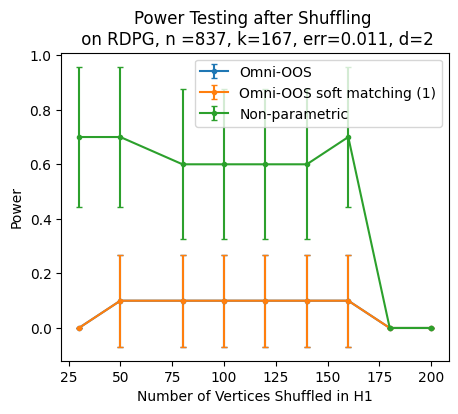

In [ ]:
plt.figure(figsize=(5,4))
# plt.plot(df2[df2.variable == 120]['lshuff'], df2[df2.variable == 120]['value'], label ='Omni-OOS')
# plt.plot(df2_avg[df2_avg.variable == 120]['lshuff'], df2_avg[df2_avg.variable == 120]['value'], label ='Omni-OOS soft matching')
# plt.plot(dff2[dff2.variable == 120]['lshuff'], dff2[dff2.variable == 120]['value'], '-.', label ='Non-parametric')
plt.errorbar(df2[df2.variable == 120]['lshuff'], df2[df2.variable == 120]['value'],yerr = df2['SE'],
             fmt ='-o',label ='Omni-OOS',capsize=2, markersize=3)
plt.errorbar(df2_avg[df2_avg.variable == 120]['lshuff'], df2_avg[df2_avg.variable == 120]['value'],yerr = df2_avg['SE'],
             fmt ='-o',label ='Omni-OOS soft matching (1)',capsize=2, markersize=3)
plt.errorbar(dff2[dff2.variable == 120]['lshuff'], dff2[dff2.variable == 120]['value'],yerr = dff2['SE'],
             fmt ='-o',label ='Non-parametric',capsize=2, markersize=3)

plt.xlabel("Number of Vertices Shuffled in H1")
plt.ylabel("Power")
plt.legend()
plt.title('Power Testing after Shuffling \n on RDPG, n =' + str(n) + 
          ', k='+str(kshuff[j])+ ', err=' + str(err)+', d=2')  # + str(err)
plt.show()

In [114]:
dff2

,lshuff,variable,value,SE
0,30.0,120,0.7,0.257697
1,50.0,120,0.7,0.257697
2,80.0,120,0.6,0.275490
3,100.0,120,0.6,0.275490
4,120.0,120,0.6,0.275490
5,140.0,120,0.6,0.275490
6,160.0,120,0.7,0.257697
7,180.0,120,0.0,0.000000
8,200.0,120,0.0,0.000000
